In [38]:
# ==========================
# Cancer Gene Expression Classification
# ==========================

import GEOparse
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier


# -------------------------------------------------
# STEP 1: Load GEO Dataset
# -------------------------------------------------

gse = GEOparse.get_GEO(
    filepath="GSE70947_family.soft.gz"
)


# -------------------------------------------------
# STEP 2: Create Expression Matrix
# Rows = Samples
# Columns = Genes
# -------------------------------------------------

expression_data = {}

for gsm_id, gsm in gse.gsms.items():

    expression_data[gsm_id] = (
        gsm.table
        .set_index("ID_REF")["VALUE"]
    )

expression_df = pd.DataFrame(expression_data).T

print("Expression Matrix Shape:")
print(expression_df.shape)


# -------------------------------------------------
# STEP 3: Convert Values → Numeric
# -------------------------------------------------

expression_df = expression_df.apply(
    pd.to_numeric,
    errors="coerce"
)


# -------------------------------------------------
# STEP 4: Create Labels
# -------------------------------------------------

labels = {}

for gsm_id, gsm in gse.gsms.items():

    title = gsm.metadata["title"][0].lower()

    labels[gsm_id] = (
        1
        if (
            "tumor" in title
            or "cancer" in title
        )
        else 0
    )

labels_df = pd.DataFrame(
    labels.items(),
    columns=["sample", "target"]
).set_index("sample")


# -------------------------------------------------
# STEP 5: Merge Expression + Labels
# -------------------------------------------------

dataset = expression_df.join(
    labels_df,
    how="inner"
)

dataset = dataset.dropna(
    subset=["target"]
)

print("\nDataset Shape:")
print(dataset.shape)


# -------------------------------------------------
# STEP 6: Split Features & Target
# -------------------------------------------------

X = dataset.drop(
    columns="target"
)

y = dataset["target"].astype(int)


# -------------------------------------------------
# STEP 7: Train Test Split
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# -------------------------------------------------
# STEP 8: Build Pipeline
# -------------------------------------------------

pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "variance_filter",
        VarianceThreshold(
            threshold=0.01
        )
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            random_state=42,
            eval_metric="logloss"
        )
    )
])


# -------------------------------------------------
# STEP 9: Train
# -------------------------------------------------

pipeline.fit(
    X_train,
    y_train
)


# -------------------------------------------------
# STEP 10: Predict
# -------------------------------------------------

y_pred = pipeline.predict(
    X_test
)


# -------------------------------------------------
# STEP 11: Evaluate
# -------------------------------------------------

print("\nAccuracy:")
print(
    accuracy_score(
        y_test,
        y_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

21-May-2026 18:49:10 INFO GEOparse - Parsing GSE70947_family.soft.gz: 
21-May-2026 18:49:10 DEBUG GEOparse - DATABASE: GeoMiame
21-May-2026 18:49:10 DEBUG GEOparse - SERIES: GSE70947
21-May-2026 18:49:10 DEBUG GEOparse - PLATFORM: GPL13607
21-May-2026 18:49:11 DEBUG GEOparse - SAMPLE: GSM1823702
21-May-2026 18:49:11 DEBUG GEOparse - SAMPLE: GSM1823703
21-May-2026 18:49:11 DEBUG GEOparse - SAMPLE: GSM1823704
21-May-2026 18:49:11 DEBUG GEOparse - SAMPLE: GSM1823705
21-May-2026 18:49:11 DEBUG GEOparse - SAMPLE: GSM1823706
21-May-2026 18:49:12 DEBUG GEOparse - SAMPLE: GSM1823707
21-May-2026 18:49:12 DEBUG GEOparse - SAMPLE: GSM1823708
21-May-2026 18:49:12 DEBUG GEOparse - SAMPLE: GSM1823709
21-May-2026 18:49:12 DEBUG GEOparse - SAMPLE: GSM1823710
21-May-2026 18:49:12 DEBUG GEOparse - SAMPLE: GSM1823711
21-May-2026 18:49:12 DEBUG GEOparse - SAMPLE: GSM1823712
21-May-2026 18:49:12 DEBUG GEOparse - SAMPLE: GSM1823713
21-May-2026 18:49:12 DEBUG GEOparse - SAMPLE: GSM1823714
21-May-2026 18:49:1

Expression Matrix Shape:
(296, 62976)

Dataset Shape:
(296, 62977)

Accuracy:
0.9166666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.87      0.91        30
           1       0.88      0.97      0.92        30

    accuracy                           0.92        60
   macro avg       0.92      0.92      0.92        60
weighted avg       0.92      0.92      0.92        60



In [40]:
#Build Gradient Boosting Classifier Pipeline
from sklearn.ensemble import GradientBoostingClassifier

gbc_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "variance_filter",
        VarianceThreshold(
            threshold=0.01
        )
    ),

    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        GradientBoostingClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            random_state=42
        )
    )

    
])

gbc_pipeline.fit(
    X_train,
    y_train
)

gbc_y_pred = gbc_pipeline.predict(
    X_test
)


print("\nGradient Boosting Accuracy:")
print(
    accuracy_score(
        y_test,
        gbc_y_pred
    )
)

print("\nGradient Boosting Classification Report:")
print(
    classification_report(
        y_test,
        gbc_y_pred
    )
)





Gradient Boosting Accuracy:
0.85

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.77      0.84        30
           1       0.80      0.93      0.86        30

    accuracy                           0.85        60
   macro avg       0.86      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60



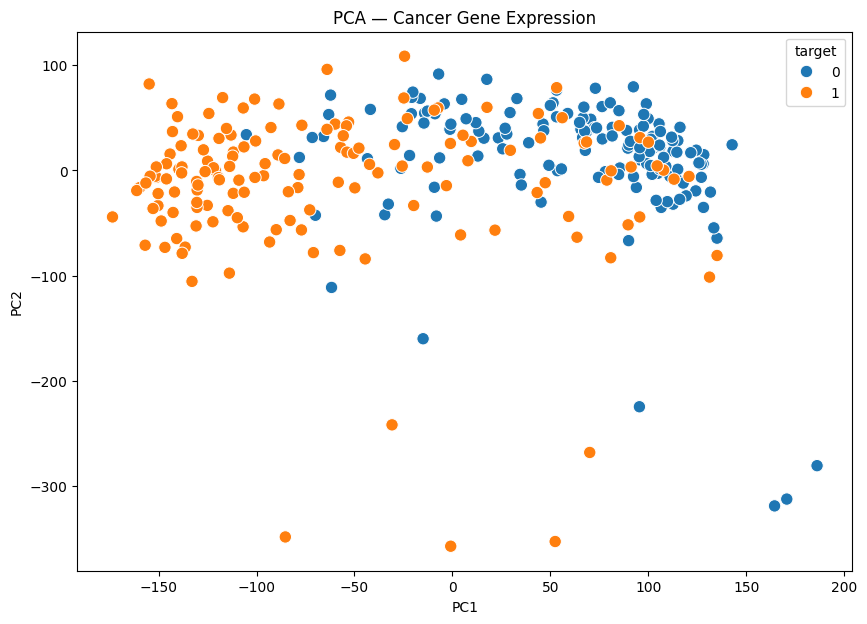

In [70]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Apply preprocessing only
X = dataset.drop(columns="target")
X_processed = pipeline[:-1].transform(X)

# PCA
pca = PCA(
    n_components=2
)

pca_result = pca.fit_transform(
    X_processed
)

# Dataframe
pca_df = pd.DataFrame({

    "PC1":
    pca_result[:,0],

    "PC2":
    pca_result[:,1],

    "target":
    y.values

})

# Plot
plt.figure(
    figsize=(10,7)
)

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="target",

    s=80

)

plt.title(
    "PCA — Cancer Gene Expression"
)

plt.show()

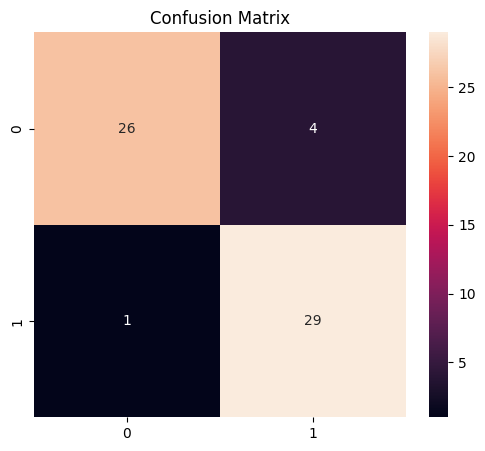

In [85]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d"

)

plt.title(
    "Confusion Matrix"
)

plt.show()

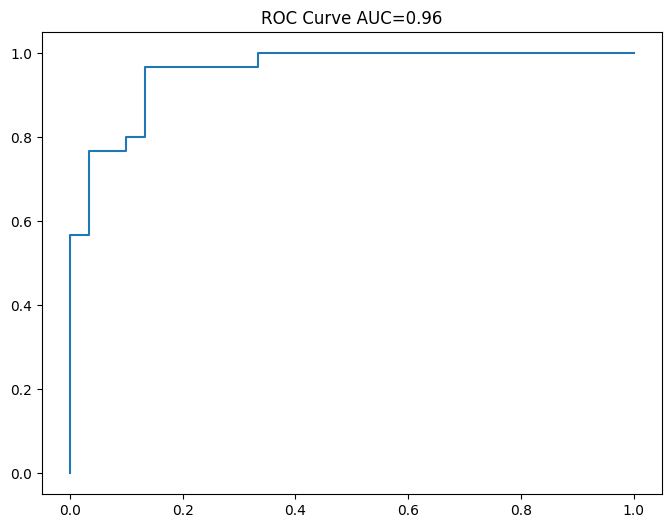

In [58]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

probs = pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(
    y_test,
    probs
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(
    figsize=(8,6)
)

plt.plot(
    fpr,
    tpr
)

plt.title(
    f"ROC Curve AUC={roc_auc:.2f}"
)

plt.show()